# AML Alert Prioritization — DnkCode

**Team 2ABB3C78 · WIUT Hackathon 2026 · FinTech / AI in Finance**

Predict the probability that an AML alert is escalated. Metric: ROC-AUC.

Design: `docs/superpowers/specs/2026-09-25-aml-alert-prioritization-design.md`  
Plan: `docs/superpowers/plans/2026-09-25-aml-alert-prioritization.md`

Every figure in the prose below is computed by a cell. Nothing is typed by hand.

In [1]:
import json
import sys
from pathlib import Path

sys.path.insert(0, '..')

import matplotlib.pyplot as plt
import pandas as pd

from src import config
from src.data import load_signals, load_transactions
from src.features import build_features, prepare_transactions
from src.models import make_factory
from src.selection import load_selection
from src.site_data import compute
from src.validation import evaluate

## The alerts

In [2]:
signals = load_signals(config.TRAIN_SIGNALS)
print('alerts:', len(signals))
print('escalation rate:', f"{signals[config.TARGET].mean():.4f}")
print('date range:', signals.signal_sanasi.min().date(), '->', signals.signal_sanasi.max().date())
signals.head()

alerts: 14000
escalation rate: 0.1718
date range: 2025-01-01 -> 2026-12-31


,signal_id,signal_sanasi,eskalatsiya
0,SG_000002,2026-08-02,0
1,SG_000003,2025-12-15,0
2,SG_000004,2026-02-13,0
3,SG_000005,2026-02-05,0
4,SG_000006,2025-04-18,0


## The transaction history

In [3]:
tx_raw = load_transactions(config.TRAIN_TX)
print('raw transactions:', len(tx_raw))
tx = prepare_transactions(tx_raw, signals)
print('after dropping days_before < 0:', len(tx))
print('dropped:', len(tx_raw) - len(tx), f"({(len(tx_raw)-len(tx))/len(tx_raw):.5%})")
tx.days_before.describe()

raw transactions: 6987663


after dropping days_before < 0: 6986823
dropped: 840 (0.01202%)


count    6.986823e+06
mean     9.423791e+01
std      5.307302e+01
min      0.000000e+00
25%      5.369584e+01
50%      9.963022e+01
75%      1.388746e+02
max      1.800000e+02
Name: days_before, dtype: float64

### Why a few transactions look like they happen after their alert

`signal_sanasi` is a date, so it parses to midnight. A transaction on the alert's
own day therefore lands fractionally *after* it — the minimum `days_before` before
filtering is about −1.0 days, not −30. It is a timestamp artifact, not leakage from
the future, and the count above shows how small it is. We drop those rows rather
than reason about them per row.

The history is otherwise bounded to a fixed 180-day window ending at the alert.
There is no long-horizon behaviour to mine.

## Exploratory views

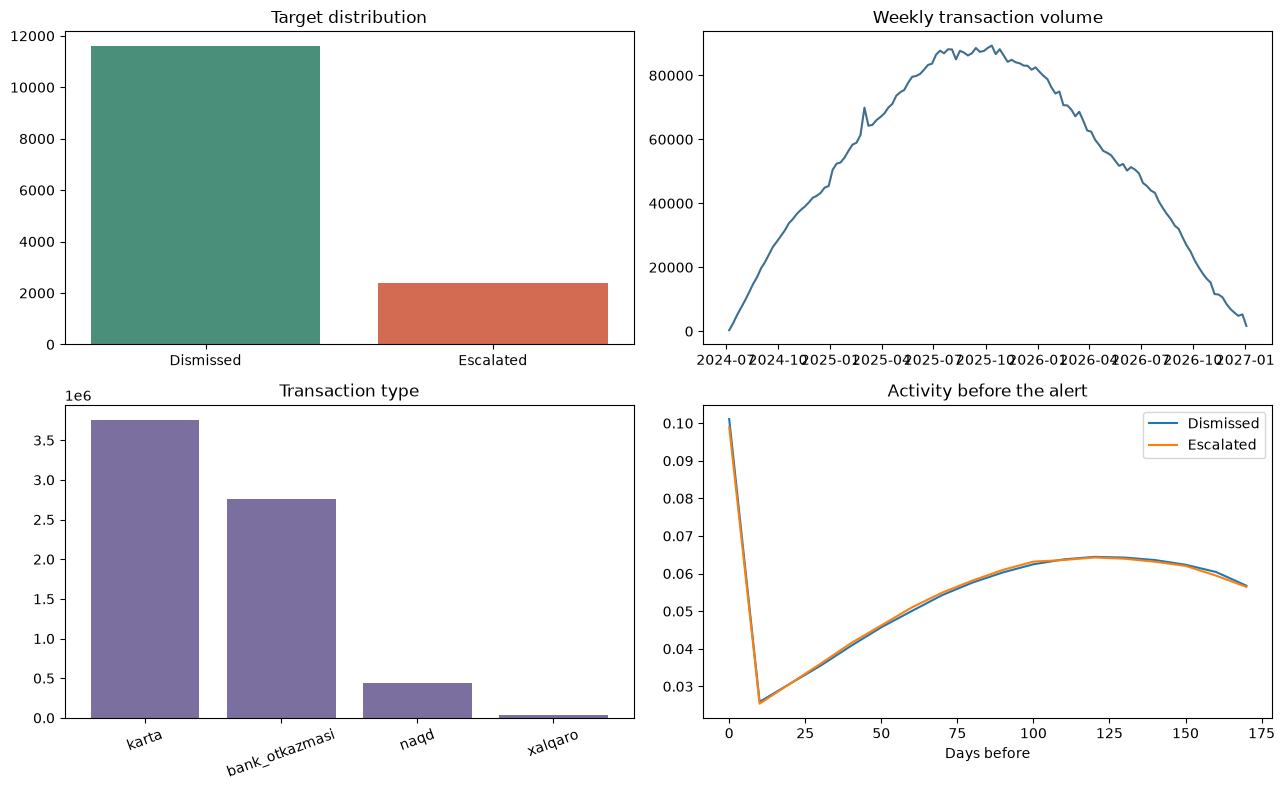

In [4]:
tables = compute(signals, tx)

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

t = tables['target']
axes[0,0].bar(t['outcome'], t['alerts'], color=['#4a8f79', '#d36a52'])
axes[0,0].set_title('Target distribution')

w = tables['weekly_volume']
axes[0,1].plot(w['tranzaksiya_vaqti'], w['transactions'], color='#3f6f8f')
axes[0,1].set_title('Weekly transaction volume')

ty = tables['types']
axes[1,0].bar(ty['type'], ty['transactions'], color='#7b6f9f')
axes[1,0].set_title('Transaction type')
axes[1,0].tick_params(axis='x', rotation=20)

h = tables['days_before_hist']
for outcome, group in h.groupby('eskalatsiya'):
    share = group['transactions'] / group['transactions'].sum()
    axes[1,1].plot(group['bucket'], share, label=outcome)
axes[1,1].set_title('Activity before the alert')
axes[1,1].set_xlabel('Days before')
axes[1,1].legend()

plt.tight_layout()

In [5]:
tables['amount_by_outcome']

,outcome,count,mean,median,std
0,Dismissed,5727482,-0.122664,-0.235195,0.985050
1,Escalated,1259341,-0.182337,-0.285375,0.961136


In [6]:
tables['volume_by_outcome']

,outcome,mean,median,min,max
0,Dismissed,493.961363,455.0,1,2279
1,Escalated,523.634511,493.0,1,2039


## The finding that shaped the model

We measured each feature family by repeated cross-validation instead of assuming it
helped. The table below is the actual forward-selection trace: every family was
offered at every round, and only the one that improved `mean − std` was accepted.

Accuracy peaks on a small set. Several families score at or below chance on their
own, and adding them costs accuracy. On this dataset the binding constraint is
variance, not model capacity.

In [7]:
summary = json.loads((config.EXPERIMENTS / 'summary.json').read_text())
history = pd.DataFrame(summary['selection_history'])
history['round'] = history.groupby('family').cumcount() + 1
history[['round', 'family', 'n_columns', 'mean', 'std', 'score', 'accepted']]

,round,family,n_columns,mean,std,score,accepted
0,1,base,7,0.568254,0.001559,0.566695,False
1,1,amount_shape,11,0.545253,0.003336,0.541917,False
2,1,direction_type,24,0.601981,0.000815,0.601166,True
3,1,cross,16,0.510618,0.001766,0.508852,False
4,1,flow,4,0.521836,0.001150,0.520686,False
5,1,windows,46,0.537235,0.002601,0.534633,False
6,1,burst,7,0.500938,0.002230,0.498708,False
7,1,hour,7,0.502910,0.003934,0.498976,False
8,1,signal_date,6,0.497418,0.001462,0.495956,False
9,2,base,31,0.616058,0.000893,0.615165,True


In [8]:
first_round = history[history['round'] == 1].sort_values('score', ascending=False)
first_round[['family', 'n_columns', 'mean', 'std', 'score']].reset_index(drop=True)

,family,n_columns,mean,std,score
0,direction_type,24,0.601981,0.000815,0.601166
1,base,7,0.568254,0.001559,0.566695
2,amount_shape,11,0.545253,0.003336,0.541917
3,windows,46,0.537235,0.002601,0.534633
4,flow,4,0.521836,0.001150,0.520686
5,cross,16,0.510618,0.001766,0.508852
6,hour,7,0.502910,0.003934,0.498976
7,burst,7,0.500938,0.002230,0.498708
8,signal_date,6,0.497418,0.001462,0.495956


In [9]:
print('families kept:', summary['families'])
print('columns kept:', summary['n_columns'])
print()
print('per-model CV mean (4 repeats of 5-fold):')
for name, mean in summary['model_cv_means'].items():
    print(f"  {name}: {mean:.5f}  (mean - std = {summary['model_scores'][name]:.5f})")
print()
print('ensemble weighting:', summary['weighting'], summary['weights'])
print(f"ensemble CV mean: {summary['ensemble_cv_mean']:.5f} "
      f"(std {summary['ensemble_cv_std']:.5f})")
print(f"best single model: {summary['best_single_model']} "
      f"{summary['best_single_cv_mean']:.5f}")
print(f"ensemble gain over best single: "
      f"{summary['ensemble_gain_over_best_single']:+.5f}")

families kept: ['direction_type', 'base']
columns kept: 19

per-model CV mean (4 repeats of 5-fold):
  lightgbm: 0.63239  (mean - std = 0.63131)
  xgboost: 0.63245  (mean - std = 0.63154)
  catboost: 0.62854  (mean - std = 0.62666)
  logreg: 0.62515  (mean - std = 0.62397)

ensemble weighting: equal {'lightgbm': 0.25, 'xgboost': 0.25, 'catboost': 0.25, 'logreg': 0.25}
ensemble CV mean: 0.63638 (std 0.00109)
best single model: xgboost 0.63245
ensemble gain over best single: +0.00393


## Reproducing the reported cross-validation score

The selection and the hyperparameter search are recorded in `experiments/log.csv`
and `experiments/summary.json`. This cell rebuilds the frozen feature set and
re-runs the harness on it, so the number below is regenerated rather than quoted.

**How the ensemble figure is computed.** A blend is scored inside each repeat and
the repeat scores are then averaged — the same way a single model is scored.
Scoring the *average* of the repeats instead inflates ROC-AUC on its own (about
0.004 at this difficulty), which would make the ensemble look better than the
models it is being compared against.

**What this estimate is not.** Feature selection and tuning both ran on these
same folds, so the figure is optimistic as an estimate of unseen performance.
It ranks our own candidates against each other honestly, which is what we used
it for; it is not a held-out estimate.

In [10]:
selection = load_selection()
X = build_features(tx, signals, families=summary['families'])[selection['columns']]
y = signals[config.TARGET]
print('feature matrix:', X.shape)

params = summary['tuned_params']['lightgbm']
result = evaluate(make_factory('lightgbm', params), X, y)
print(f'LightGBM repeated CV: mean={result.mean:.5f} std={result.std:.5f} score={result.score:.5f}')

feature matrix: (14000, 19)


LightGBM repeated CV: mean=0.63239 std=0.00108 score=0.63131


## What the model actually uses

/Users/baxrom/ish_full/WiutHackaton/.venv/lib/python3.14/site-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


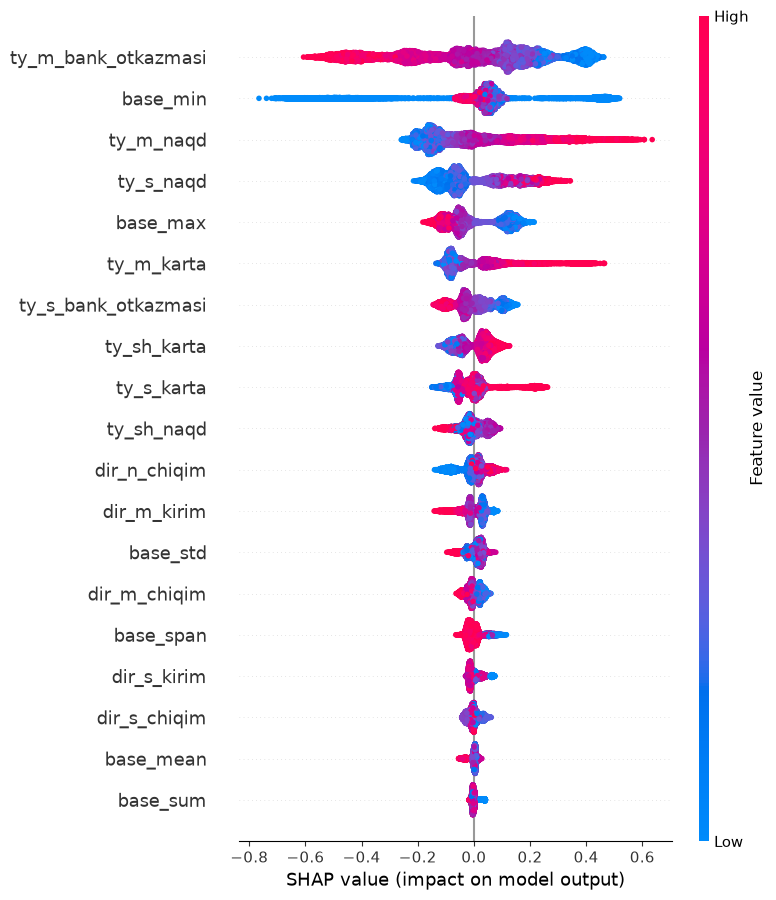

In [11]:
import shap

model = make_factory('lightgbm', params)(config.SEED)
model.fit(X.fillna(X.median()), y)
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X.fillna(X.median()))
shap.summary_plot(shap_values, X.fillna(X.median()), max_display=20, show=True)

## Submission

The prediction file is produced by `python -m src.pipeline`, which refuses to write
unless every competition rule passes. The cell below reproduces it from the frozen
selection and tuned parameters — no new search — and prints the rule check.

In [12]:
if config.TEST_TX.exists():
    from src.pipeline import predict_from_saved
    try:
        predict_from_saved()
    except Exception as exc:
        print('Submission step could not run:', exc)
else:
    print('test_transactions.parquet is absent; run `python -m src.pipeline` once it is in place.')

Adversarial validation AUC: 0.4921
Top drifting columns:
 base_span       4203.0
ty_sh_naqd      3545.0
base_max        3508.0
base_std        3483.0
dir_n_chiqim    3374.0
base_min        3350.0
ty_sh_karta     3136.0
ty_m_naqd       2973.0
ty_s_naqd       2737.0
dir_s_chiqim    2668.0
dtype: float64


[PASS] columns are exactly [signal_id, ehtimollik] (got ['signal_id', 'ehtimollik'])
[PASS] row count matches test signals (6000 rows vs 6000 expected)
[PASS] no missing IDs (0 missing)
[PASS] no extra IDs (0 extra)
[PASS] no duplicate IDs (0 duplicated)
[PASS] no null probabilities (0 null)
[PASS] all probabilities within [0, 1] (0 out of range)
[PASS] predictions are not a constant placeholder (5537 distinct value(s))
Wrote /Users/baxrom/ish_full/WiutHackaton/outputs/team_2ABB3C78.csv


## Conclusion

A compact, measured feature set with a regularized, seed-bagged ensemble ranks
alerts better than a larger feature set does. The discipline that mattered was
honest validation: on 14,000 rows with this little signal, a difference smaller
than the repeat-to-repeat standard deviation is not an improvement, and treating
it as one is how a model that looks good locally fails on the leaderboard.

Everything above is reproducible from `src/` with `SEED = 42`.